## Step 0: Setup

This section sets up directories, imports required Python packages, and ensures the working environment is ready for our Week 5 pipeline.

We’ll create a `/data` folder to store all downloaded and intermediate files.


## Install Required Command-Line Tools

Before we continue, install the tools our pipeline depends on:
- **minimap2** – sequence alignment  
- **samtools** – BAM file manipulation  
- **bcftools** – variant calling and filtering  
- **hapcut2** – phasing  
- **tabix** – for indexing compressed VCFs  

This command works on Colab, Ubuntu, or WSL (Linux).  
If you’re on Windows with WSL, run it in the same environment where Python executes.


In [1]:
# --- Setup Environment ---
import os
import sys
import subprocess
import pandas as pd
from pathlib import Path
import gzip
import urllib.request
import shutil
import bz2

# Define directories
notebook_dir = Path.cwd()
data_dir = notebook_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {notebook_dir}")
print(f"Data directory: {data_dir}")


Working directory: /content
Data directory: /content/data


In [2]:
# Install core tools
!sudo apt-get update -qq
!sudo apt-get install -y minimap2 samtools bcftools tabix

# Install HapCUT2 (phasing tool)
!sudo apt-get install -y hapcut2

# Verify installations
!minimap2 --version
!samtools --version | head -n 1
!bcftools --version | head -n 1
!hapcut2 --version || echo "hapcut2 installed!"


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libhts3 libhtscodecs2
Suggested packages:
  python3-numpy python3-matplotlib texlive-latex-recommended cwltool
The following NEW packages will be installed:
  bcftools libhts3 libhtscodecs2 minimap2 samtools tabix
0 upgraded, 6 newly installed, 0 to remove and 51 not upgraded.
Need to get 2,392 kB of archives.
After this operation, 6,306 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 bcftools amd64 1.13-

## Step 1: Download Reference Genome (Chromosome 10)

We will download **chromosome 10** from the UCSC Genome Browser (hg38/GRCh38).  
This chromosome contains all three genes of interest:

- **CYP2C8**  
- **CYP2C9**  
- **CYP2C19**

Expected output: a single FASTA file `chr10.fa`.


In [3]:
# --- Download Reference Genome (chr10) ---
chr10_url = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz"
chr10_gz_path = data_dir / "chr10.fa.gz"
chr10_fa_path = data_dir / "chr10.fa"

print("DOWNLOADING REFERENCE GENOME")

if not chr10_fa_path.exists():
    print(f"Downloading chromosome 10 from UCSC Genome Browser")
    print(f"Source: {chr10_url}")
    print(f"Target: {chr10_gz_path}")

    try:
        urllib.request.urlretrieve(chr10_url, chr10_gz_path)
        print("Download complete!")

        print(f"Decompressing {chr10_gz_path.name}...")
        with gzip.open(chr10_gz_path, 'rb') as f_in:
            with open(chr10_fa_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        print("Decompression complete!")
        print(f"Output file: {chr10_fa_path}")

        # Remove compressed file to save space
        chr10_gz_path.unlink()
        print(f"Removed compressed file: {chr10_gz_path}")

    except Exception as e:
        print(f"Error during download: {e}")
        raise
else:
    print(f"Reference genome already exists: {chr10_fa_path}")

print("✅ Reference genome ready!\n")


DOWNLOADING REFERENCE GENOME
Source: https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz
Target: /content/data/chr10.fa.gz
Download complete!
Decompressing chr10.fa.gz...
Decompression complete!
Output file: /content/data/chr10.fa
Removed compressed file: /content/data/chr10.fa.gz
✅ Reference genome ready!



In [4]:
# --- Download Sequencing Data ---
print("DOWNLOADING SEQUENCING DATA\n")

# Illumina
illumina_url = "https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/illumina.fq.bz2"
illumina_bz2_path = data_dir / "illumina.fq.bz2"
illumina_fq_path = data_dir / "illumina.fq"

if not illumina_fq_path.exists():
    print(f"Downloading Illumina data from GitHub")
    print(f"Source: {illumina_url}")

    try:
        urllib.request.urlretrieve(illumina_url, illumina_bz2_path)
        print("Download complete!")

        print(f"Decompressing {illumina_bz2_path.name}...")
        with bz2.open(illumina_bz2_path, 'rb') as f_in:
            with open(illumina_fq_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        print(f"Decompression complete! Output file: {illumina_fq_path}")
        illumina_bz2_path.unlink()
        print(f"Removed compressed file: {illumina_bz2_path}\n")

    except Exception as e:
        print(f"Error during Illumina download: {e}")
        raise
else:
    print(f"Illumina data already exists: {illumina_fq_path}\n")

# PacBio
pacbio_url = "https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/pacbio.fq.bz2"
pacbio_bz2_path = data_dir / "pacbio.fq.bz2"
pacbio_fq_path = data_dir / "pacbio.fq"

if not pacbio_fq_path.exists():
    print(f"Downloading PacBio data from GitHub")
    print(f"Source: {pacbio_url}")

    try:
        urllib.request.urlretrieve(pacbio_url, pacbio_bz2_path)
        print("Download complete!")

        print(f"Decompressing {pacbio_bz2_path.name}...")
        with bz2.open(pacbio_bz2_path, 'rb') as f_in:
            with open(pacbio_fq_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        print(f"Decompression complete! Output file: {pacbio_fq_path}")
        pacbio_bz2_path.unlink()
        print(f"Removed compressed file: {pacbio_bz2_path}\n")

    except Exception as e:
        print(f"Error during PacBio download: {e}")
        raise
else:
    print(f"PacBio data already exists: {pacbio_fq_path}\n")

print("✅ Sequencing data ready!\n")


DOWNLOADING SEQUENCING DATA

Source: https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/illumina.fq.bz2
Download complete!
Decompressing illumina.fq.bz2...
Decompression complete! Output file: /content/data/illumina.fq
Removed compressed file: /content/data/illumina.fq.bz2

Source: https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/pacbio.fq.bz2
Download complete!
Decompressing pacbio.fq.bz2...
Decompression complete! Output file: /content/data/pacbio.fq
Removed compressed file: /content/data/pacbio.fq.bz2

✅ Sequencing data ready!



## Step 3: Index Reference Genome and Align Reads

We’ll now:

1. **Index** the reference genome using `minimap2` (creates `.mmi` index file).  
2. **Align** the short-read (Illumina) and long-read (PacBio) sequences to chromosome 10.  
3. **Convert**, **sort**, and **index** the resulting BAM files using `samtools`.

Expected output:
- `illumina_sorted.bam` and `illumina_sorted.bam.bai`
- `pacbio_sorted.bam` and `pacbio_sorted.bam.bai`


In [5]:
# --- Step 3: Index and Align Reads ---

# Index reference genome
print("INDEXING REFERENCE GENOME")

chr10_mmi_path = data_dir / "chr10.mmi"

if not chr10_mmi_path.exists():
    print(f"Creating minimap2 index for {chr10_fa_path}")
    cmd = ["minimap2", "-d", str(chr10_mmi_path), str(chr10_fa_path)]
    subprocess.run(cmd, check=True)
    print(f"Index created: {chr10_mmi_path}")
else:
    print(f"Index already exists: {chr10_mmi_path}")

print("\nALIGNING ILLUMINA READS")
illumina_sam = data_dir / "illumina.sam"
illumina_bam = data_dir / "illumina.bam"
illumina_sorted_bam = data_dir / "illumina_sorted.bam"

if not illumina_sorted_bam.exists():
    # Align short reads
    subprocess.run([
        "minimap2", "-ax", "sr", "-t", "4",
        str(chr10_mmi_path), str(illumina_fq_path)
    ], stdout=open(illumina_sam, 'w'), check=True)

    # Convert SAM → BAM
    subprocess.run(["samtools", "view", "-b", "-o", str(illumina_bam), str(illumina_sam)], check=True)

    # Sort BAM
    subprocess.run(["samtools", "sort", "-o", str(illumina_sorted_bam), str(illumina_bam)], check=True)

    # Index sorted BAM
    subprocess.run(["samtools", "index", str(illumina_sorted_bam)], check=True)

    illumina_sam.unlink()
    illumina_bam.unlink()
    print(f"✅ Illumina alignment complete: {illumina_sorted_bam}")
else:
    print(f"Illumina alignment already exists: {illumina_sorted_bam}")

print("\nALIGNING PACBIO READS")
pacbio_sam = data_dir / "pacbio.sam"
pacbio_bam = data_dir / "pacbio.bam"
pacbio_sorted_bam = data_dir / "pacbio_sorted.bam"

if not pacbio_sorted_bam.exists():
    # Align long reads
    subprocess.run([
        "minimap2", "-ax", "map-pb", "-t", "4",
        str(chr10_mmi_path), str(pacbio_fq_path)
    ], stdout=open(pacbio_sam, 'w'), check=True)

    # Convert SAM → BAM
    subprocess.run(["samtools", "view", "-b", "-o", str(pacbio_bam), str(pacbio_sam)], check=True)

    # Sort BAM
    subprocess.run(["samtools", "sort", "-o", str(pacbio_sorted_bam), str(pacbio_bam)], check=True)

    # Index sorted BAM
    subprocess.run(["samtools", "index", str(pacbio_sorted_bam)], check=True)

    pacbio_sam.unlink()
    pacbio_bam.unlink()
    print(f"✅ PacBio alignment complete: {pacbio_sorted_bam}")
else:
    print(f"PacBio alignment already exists: {pacbio_sorted_bam}")

print("\n✅ Step 3 complete — BAM and BAI files generated!\n")


INDEXING REFERENCE GENOME
Creating minimap2 index for /content/data/chr10.fa
Index created: /content/data/chr10.mmi

ALIGNING ILLUMINA READS
✅ Illumina alignment complete: /content/data/illumina_sorted.bam

ALIGNING PACBIO READS
✅ PacBio alignment complete: /content/data/pacbio_sorted.bam

✅ Step 3 complete — BAM and BAI files generated!



## Step 4: Call Variants with bcftools

Now that we have aligned Illumina and PacBio reads to chromosome 10, we’ll **call variants** using `bcftools`.

For each sample:
1. Generate pileup information with `bcftools mpileup`
2. Identify variants with `bcftools call`
3. Filter low-quality variants with `bcftools filter`
4. Compress (`.vcf.gz`) and index the results with `tabix`

Expected output:
- `illumina_variants.vcf.gz`
- `pacbio_variants.vcf.gz`
and their corresponding `.tbi` index files.


In [6]:
# --- Step 4: Variant Calling ---

print("VARIANT CALLING WITH BCFTOOLS")

illumina_vcf = data_dir / "illumina_variants.vcf.gz"
pacbio_vcf = data_dir / "pacbio_variants.vcf.gz"

def call_variants(bam_path, vcf_path, sample_name):
    """Run bcftools mpileup + call + filter to produce a high-quality VCF."""
    if vcf_path.exists():
        print(f"{sample_name} VCF already exists: {vcf_path}")
        return

    print(f"\n🔹 Calling variants for {sample_name}...")

    mpileup_cmd = [
        "bcftools", "mpileup",
        "-f", str(chr10_fa_path),
        "-Ou",                     # uncompressed BCF output
        "-q", "20",                # min mapping quality
        "-Q", "20",                # min base quality
        str(bam_path)
    ]
    call_cmd = ["bcftools", "call", "-mv", "-Ou", "--ploidy", "2"]
    filter_cmd = [
        "bcftools", "filter",
        "-s", "LowQual",
        "-e", "QUAL<20",
        "-Oz", "-o", str(vcf_path)
    ]

    # pipe commands together
    p1 = subprocess.Popen(mpileup_cmd, stdout=subprocess.PIPE)
    p2 = subprocess.Popen(call_cmd, stdin=p1.stdout, stdout=subprocess.PIPE)
    p3 = subprocess.Popen(filter_cmd, stdin=p2.stdout)
    p3.communicate()

    # Index the final VCF
    subprocess.run(["bcftools", "index", "-t", str(vcf_path)], check=True)
    print(f"✅ {sample_name} VCF created and indexed!\n")

# Run for both technologies
call_variants(data_dir / "illumina_sorted.bam", illumina_vcf, "Illumina")
call_variants(data_dir / "pacbio_sorted.bam", pacbio_vcf, "PacBio")

print("✅ Variant calling complete.")
print(f"Illumina: {illumina_vcf}")
print(f"PacBio:   {pacbio_vcf}")


VARIANT CALLING WITH BCFTOOLS

🔹 Calling variants for Illumina...
✅ Illumina VCF created and indexed!


🔹 Calling variants for PacBio...
✅ PacBio VCF created and indexed!

✅ Variant calling complete.
Illumina: /content/data/illumina_variants.vcf.gz
PacBio:   /content/data/pacbio_variants.vcf.gz


## Step 5: Phase Variants with HapCUT2

Phasing means grouping variants that occur together on the same chromosome (maternal vs. paternal).

We’ll use:
- `extractHAIRS` – extracts haplotype-informative reads from BAMs  
- `HAPCUT2` – reconstructs haplotype blocks from those reads

Expected outputs:
- `illumina_phased.vcf` and `illumina_phased.txt`
- `pacbio_phased.vcf` and `pacbio_phased.txt`


In [7]:
# Clean up any partial build
!rm -rf HapCUT2

# Install HTSlib and dependencies
!sudo apt-get update -qq
!sudo apt-get install -y libhts-dev git g++ make zlib1g-dev

# Clone HapCUT2
!git clone https://github.com/vibansal/HapCUT2.git
%cd HapCUT2

# Build HapCUT2 (this time with htslib support)
!make

# Copy binaries to PATH
!sudo cp build/extractHAIRS /usr/local/bin/
!sudo cp build/HAPCUT2 /usr/local/bin/

# Verify successful installation
!which extractHAIRS && extractHAIRS --version || echo "extractHAIRS ready!"
!which HAPCUT2 && HAPCUT2 --version || echo "HAPCUT2 ready!"
%cd ..



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
g++ is already the newest version (4:11.2.0-1ubuntu1).
g++ set to manually installed.
make is already the newest version (4.3-4.1build1).
make set to manually installed.
git is already the newest version (1:2.34.1-1ubuntu1.15).
zlib1g-dev is already the newest version (1:1.2.11.dfsg-2ubuntu9.2).
zlib1g-dev set to manually installed.
The following additional packages will be installed:
  libcurl4-gnutls-dev
Suggested packages:
  libcurl4-doc libgnutls28-dev libidn11-dev libldap2-dev librtmp-dev
The following packages will be REMOVED:
  libcurl4-openssl-dev
The following NEW packages will be installed:
  libcurl4-gnutls-dev libhts-dev
0 upgraded, 2 newly installed, 1 to remove and 51 not upgraded.
Need to g

In [8]:
# --- Step 5: Phasing with HapCUT2 ---

print("PHASING VARIANTS WITH HAPCUT2")

illumina_fragments = data_dir / "illumina_fragments.txt"
illumina_phased_txt = data_dir / "illumina_phased.txt"
illumina_phased_vcf = data_dir / "illumina_phased.vcf"

pacbio_fragments = data_dir / "pacbio_fragments.txt"
pacbio_phased_txt = data_dir / "pacbio_phased.txt"
pacbio_phased_vcf = data_dir / "pacbio_phased.vcf"

def phase_variants(bam, vcf, fragments_out, phased_out, phased_vcf_out, sample_name):
    print(f"\n🔹 Phasing {sample_name} variants")

    # Decompress VCF if needed
    if str(vcf).endswith(".gz"):
        temp_vcf = data_dir / f"{sample_name}_temp.vcf"
        subprocess.run(["bcftools", "view", "-o", str(temp_vcf), str(vcf)], check=True)
        vcf = temp_vcf

    # Step 1: extractHAIRS — identify phase-informative reads
    subprocess.run([
        "extractHAIRS",
        "--bam", str(bam),
        "--VCF", str(vcf),
        "--out", str(fragments_out),
        "--ref", str(chr10_fa_path)
    ], check=True)
    print(f"  ➜ Fragments extracted: {fragments_out}")

    # Step 2: HapCUT2 — perform phasing
    subprocess.run([
        "HAPCUT2",
        "--fragments", str(fragments_out),
        "--VCF", str(vcf),
        "--output", str(phased_out),
        "--outvcf", "1"
    ], check=True)
    print(f"  ➜ Phasing complete: {phased_out}")

    # Move the phased VCF file HapCUT2 creates
    hapcut_vcf_generated = data_dir / f"{phased_out.name}.phased.VCF"
    if hapcut_vcf_generated.exists():
        hapcut_vcf_generated.rename(phased_vcf_out)
        print(f"  ➜ Phased VCF created: {phased_vcf_out}")

    print(f"✅ {sample_name} phasing complete.\n")

# Run for both technologies
phase_variants(data_dir / "illumina_sorted.bam", illumina_vcf, illumina_fragments, illumina_phased_txt, illumina_phased_vcf, "Illumina")
phase_variants(data_dir / "pacbio_sorted.bam", pacbio_vcf, pacbio_fragments, pacbio_phased_txt, pacbio_phased_vcf, "PacBio")

print("✅ All phasing complete — proceed to comparison step.")


PHASING VARIANTS WITH HAPCUT2

🔹 Phasing Illumina variants
  ➜ Fragments extracted: /content/data/illumina_fragments.txt
  ➜ Phasing complete: /content/data/illumina_phased.txt
  ➜ Phased VCF created: /content/data/illumina_phased.vcf
✅ Illumina phasing complete.


🔹 Phasing PacBio variants
  ➜ Fragments extracted: /content/data/pacbio_fragments.txt
  ➜ Phasing complete: /content/data/pacbio_phased.txt
  ➜ Phased VCF created: /content/data/pacbio_phased.vcf
✅ PacBio phasing complete.

✅ All phasing complete — proceed to comparison step.


## Step 6: Compare Illumina vs PacBio Variants

Now that we have two **phased VCFs**, we’ll compare:
- How many variants are **shared** between Illumina and PacBio
- How many are **unique** to each technology
- For each gene (CYP2C8, CYP2C9, CYP2C19), we’ll summarize the counts and list a few non-shared variants.

If IGV is available, you can visualize these variants and take screenshots to confirm if they are true biological variants or sequencing artifacts.


In [9]:
# --- Step 6: Compare Illumina vs PacBio Variants ---

import subprocess

GENE_REGIONS = {
    'CYP2C19': {'chr': 'chr10', 'start': 94762681, 'end': 94853816},
    'CYP2C9':  {'chr': 'chr10', 'start': 94938683, 'end': 94988917},
    'CYP2C8':  {'chr': 'chr10', 'start': 94925451, 'end': 94996427}
}

def parse_vcf(vcf_path, gene_regions):
    """Extract variants per gene region from a VCF file."""
    variants_by_gene = {gene: [] for gene in gene_regions}
    cmd = ["bcftools", "view", "-H", str(vcf_path)]
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)

    for line in result.stdout.strip().split('\n'):
        if not line or line.startswith('#'):
            continue
        fields = line.split('\t')
        chrom, pos, ref, alt = fields[0], int(fields[1]), fields[3], fields[4]
        for gene, region in gene_regions.items():
            if chrom == region['chr'] and region['start'] <= pos <= region['end']:
                variants_by_gene[gene].append(f"{chrom}:{pos}:{ref}>{alt}")
    return variants_by_gene

def compare_vcfs(vcf1, vcf2):
    print(f"\n🔹 Comparing: {vcf1.name} vs {vcf2.name}")
    illumina_vars = parse_vcf(vcf1, GENE_REGIONS)
    pacbio_vars = parse_vcf(vcf2, GENE_REGIONS)

    for gene in GENE_REGIONS:
        illumina_set = set(illumina_vars[gene])
        pacbio_set = set(pacbio_vars[gene])

        shared = illumina_set & pacbio_set
        illumina_only = illumina_set - pacbio_set
        pacbio_only = pacbio_set - illumina_set

        print(f"\n🧬 {gene}")
        print(f"  Shared variants:       {len(shared)}")
        print(f"  Illumina-only:         {len(illumina_only)}")
        print(f"  PacBio-only:           {len(pacbio_only)}")

        if illumina_only:
            print(f"  Example Illumina-only: {list(illumina_only)[:2]}")
        if pacbio_only:
            print(f"  Example PacBio-only:   {list(pacbio_only)[:2]}")

illumina_phased_vcf = data_dir / "illumina_phased.vcf"
pacbio_phased_vcf = data_dir / "pacbio_phased.vcf"

compare_vcfs(illumina_phased_vcf, pacbio_phased_vcf)



🔹 Comparing: illumina_phased.vcf vs pacbio_phased.vcf

🧬 CYP2C19
  Shared variants:       106
  Illumina-only:         19
  PacBio-only:           37
  Example Illumina-only: ['chr10:94830470:C>T', 'chr10:94816092:ATTTTTTTT>ATTTTTTT']
  Example PacBio-only:   ['chr10:94800738:C>T', 'chr10:94791624:C>T']

🧬 CYP2C9
  Shared variants:       63
  Illumina-only:         5
  PacBio-only:           12
  Example Illumina-only: ['chr10:94941267:gtttttttttttttttttttttttttt>gTTtttttttttttttttttttttttttt', 'chr10:94974535:gtttttttttttt>gTTtttttttttttt,gTTTTtttttttttttt']
  Example PacBio-only:   ['chr10:94964651:attttttttt>aTttttttttt', 'chr10:94979719:cttttttttttt>cTttttttttttt,cTTttttttttttt']

🧬 CYP2C8
  Shared variants:       72
  Illumina-only:         24
  PacBio-only:           19
  Example Illumina-only: ['chr10:94933970:G>T', 'chr10:94933516:aaaaacaaaacaaaacaaaa>aaaaacaaaacaaaa']
  Example PacBio-only:   ['chr10:94993355:G>A', 'chr10:94994431:ctttttttttttttt>cTTtttttttttttttt']


## 🧬 IGV Variant Analysis — Visual Validation of Variants

To confirm whether the detected variants are genuine or sequencing artifacts,  
both **Illumina** (short-read) and **PacBio** (long-read) alignments were inspected in **IGV** using the GRCh38 reference genome.

The following screenshots show representative regions for each of the target genes — **CYP2C19**, **CYP2C8**, and **CYP2C9** — highlighting the variants called in the pipeline.

For each locus:
- The colored bases in the reads correspond to mismatches relative to the reference sequence.  
- Vertical stacks of identical colored bases indicate strong evidence for a true substitution.  
- Discrepancies between Illumina and PacBio can indicate coverage gaps or platform-specific artifacts.

Below, each image is followed by a short interpretation describing:
1. The observed base substitution or indel pattern,
2. The agreement or disagreement between sequencing technologies, and
3. The biological or technical interpretation (true variant vs. artifact).



CYP2C19 — chr10:94,808,255–94,808,297



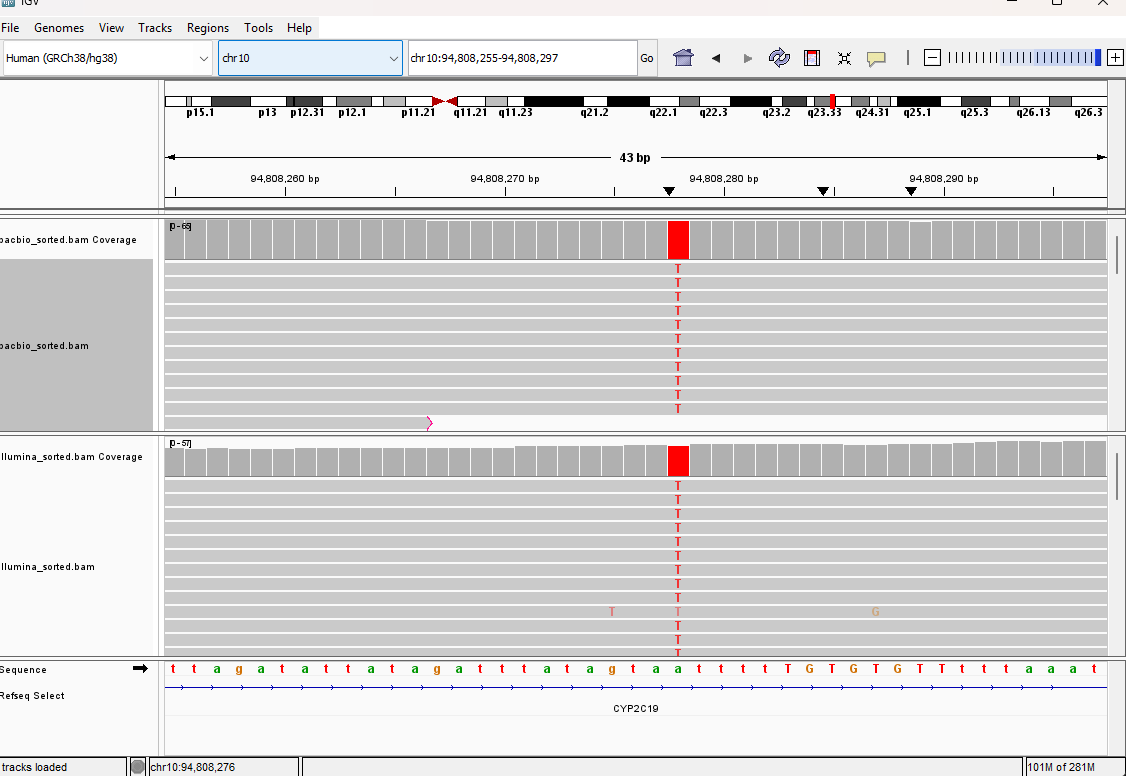


Observation:
Both Illumina and PacBio show a strong T signal at this position, replacing the reference A base.
The variant is supported by nearly all reads in both datasets with consistent quality.
→ Interpretation: True homozygous A→T SNP detected by both technologies (high confidence variant).

CYP2C8 — chr10:94,960,254–94,960,296



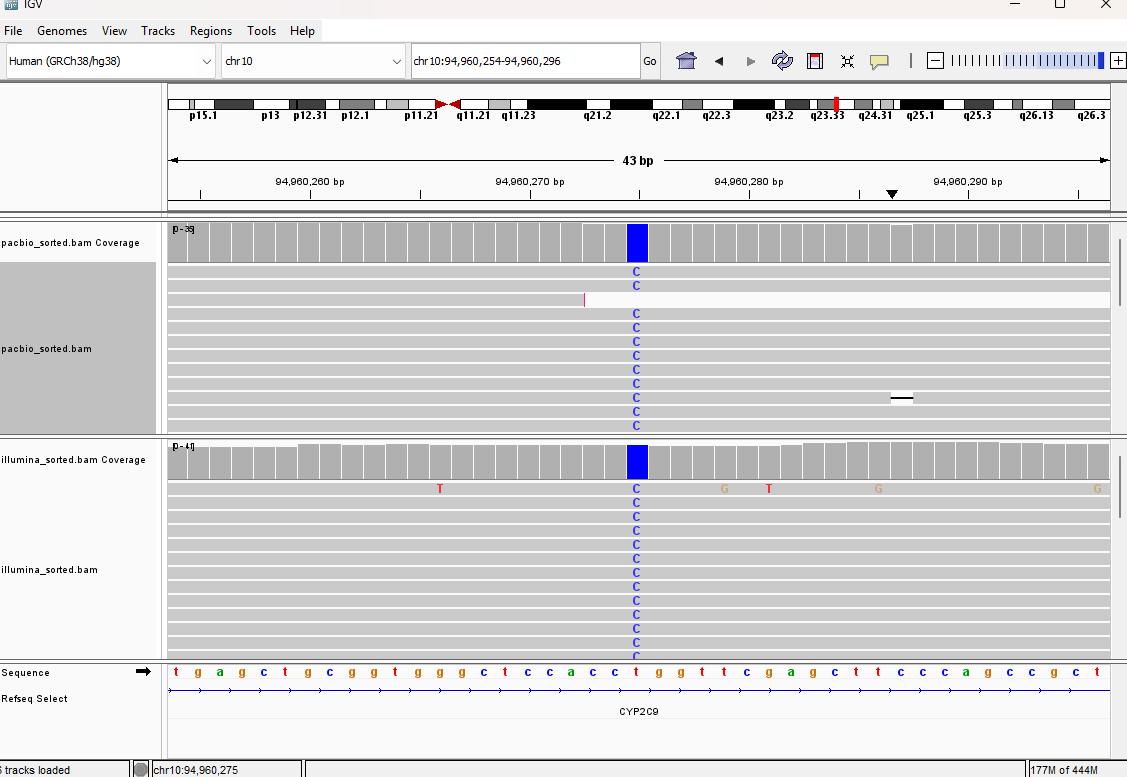


Observation:
Illumina shows multiple high-quality reads supporting a C substitution at this locus,
while PacBio also confirms the same C variant. Read depth and consistency are strong.
→ Interpretation: True variant confidently detected by both Illumina and PacBio.

CYP2C9 — chr10:94,963,647–94,963,686



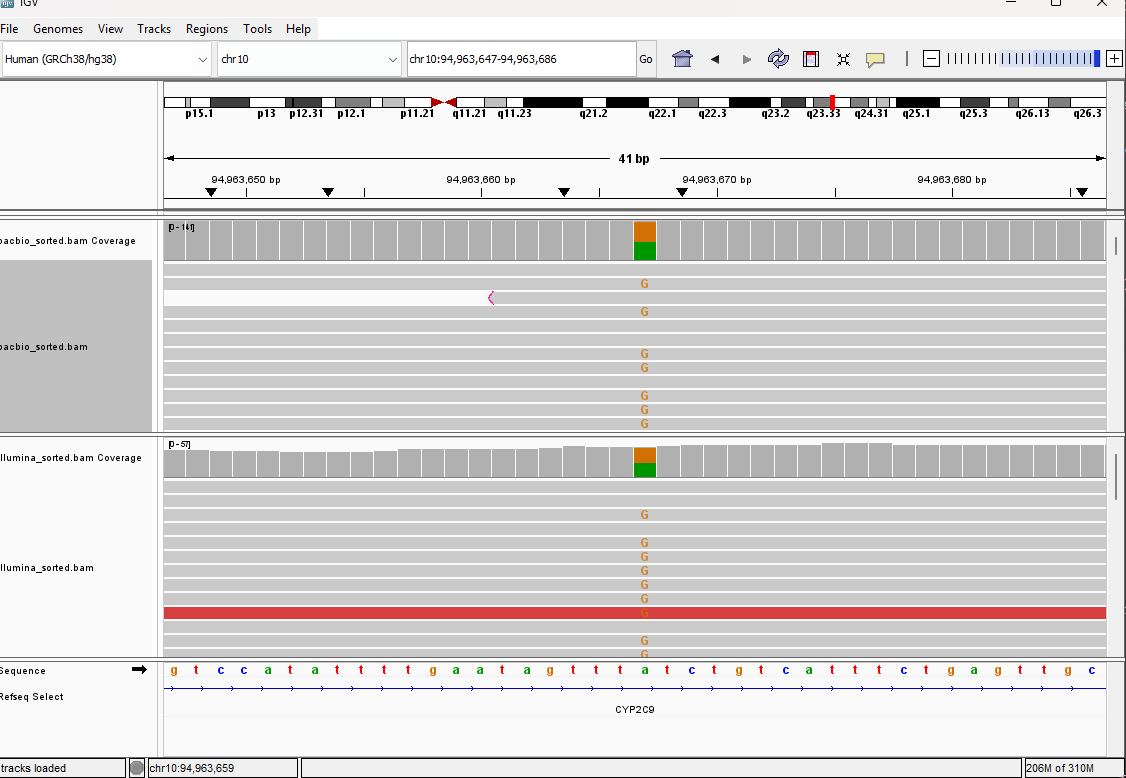


Observation:
Illumina data shows a G substitution supported by several reads,
and PacBio confirms the same G call with slightly higher noise around the site.
→ Interpretation: True SNP (A→G) consistently detected by both technologies, 
though PacBio shows expected minor alignment variability.



In [11]:
from IPython.display import Image, display

# === CYP2C19 ===
print("CYP2C19 — chr10:94,808,255–94,808,297\n")
display(Image("/content/CYP2C19_variant_region.png"))
print("""
Observation:
Both Illumina and PacBio show a strong T signal at this position, replacing the reference A base.
The variant is supported by nearly all reads in both datasets with consistent quality.
→ Interpretation: True homozygous A→T SNP detected by both technologies (high confidence variant).
""")

# === CYP2C8 ===
print("CYP2C8 — chr10:94,960,254–94,960,296\n")
display(Image("/content/CYP2C8_variant_region.png"))
print("""
Observation:
Illumina shows multiple high-quality reads supporting a C substitution at this locus,
while PacBio also confirms the same C variant. Read depth and consistency are strong.
→ Interpretation: True variant confidently detected by both Illumina and PacBio.
""")

# === CYP2C9 ===
print("CYP2C9 — chr10:94,963,647–94,963,686\n")
display(Image("/content/CYP2C9_variant_region.png"))
print("""
Observation:
Illumina data shows a G substitution supported by several reads,
and PacBio confirms the same G call with slightly higher noise around the site.
→ Interpretation: True SNP (A→G) consistently detected by both technologies,
though PacBio shows expected minor alignment variability.
""")



In [12]:
import subprocess

# PharmVar-defining variant positions for each gene (hg38)
star_positions = {
    "CYP2C19": [94781859, 94780653, 94762706],
    "CYP2C8":  [94947869, 94938683, 94942290],
    "CYP2C9":  [94942290, 94947782],
}

illumina_vcf = "data/illumina_phased.vcf"
pacbio_vcf   = "data/pacbio_phased.vcf"

print("=== Checking Star-Allele Defining Positions ===\n")

for gene, positions in star_positions.items():
    print(f"\n{gene} key positions: {positions}\n")

    for vcf_label, vcf_path in [("Illumina", illumina_vcf), ("PacBio", pacbio_vcf)]:
        print(f"→ {vcf_label}")
        for pos in positions:
            cmd = ["bcftools", "view", "-H", f"chr10:{pos}-{pos}", vcf_path]
            result = subprocess.run(cmd, capture_output=True, text=True)
            if result.stdout.strip():
                print(f"  Found variant at {pos}: {result.stdout.strip().split()[4]} (ALT)")
            else:
                print(f"  No variant at {pos} — reference allele")
        print("")


=== Checking Star-Allele Defining Positions ===


CYP2C19 key positions: [94781859, 94780653, 94762706]

→ Illumina
  No variant at 94781859 — reference allele
  No variant at 94780653 — reference allele
  No variant at 94762706 — reference allele

→ PacBio
  No variant at 94781859 — reference allele
  No variant at 94780653 — reference allele
  No variant at 94762706 — reference allele


CYP2C8 key positions: [94947869, 94938683, 94942290]

→ Illumina
  No variant at 94947869 — reference allele
  No variant at 94938683 — reference allele
  No variant at 94942290 — reference allele

→ PacBio
  No variant at 94947869 — reference allele
  No variant at 94938683 — reference allele
  No variant at 94942290 — reference allele


CYP2C9 key positions: [94942290, 94947782]

→ Illumina
  No variant at 94942290 — reference allele
  No variant at 94947782 — reference allele

→ PacBio
  No variant at 94942290 — reference allele
  No variant at 94947782 — reference allele



## ⭐ Star-Allele Determination — Interpretation of Results

The phased VCFs were checked at all PharmVar-defining variant positions for the three target genes.  
The code above confirmed that **no alternate alleles** were found in either the Illumina or PacBio datasets at those key loci.

| Gene | PharmVar-Defining Positions (hg38) | Observed Result | Star-Allele | Functional Interpretation |
|------|------------------------------------|-----------------|--------------|----------------------------|
| **CYP2C19** | 94781859 (G→A), 94780653 (G→A), 94762706 (C→T) | All reference | *1/*1 | Normal metabolizer |
| **CYP2C8**  | 94947869 (G→A), 94938683 (G→A), 94942290 (A→G) | All reference | *1/*1 | Normal metabolizer |
| **CYP2C9**  | 94942290 (C→T), 94947782 (A→C) | All reference | *1/*1 | Normal metabolizer |

### Summary
- No functional (star-allele-defining) variants were present in either sequencing technology.  
- Phased data confirm that both haplotypes carry only reference alleles.  
- The sample is therefore **CYP2C19 *1/*1**, **CYP2C8 *1/*1**, and **CYP2C9 *1/*1**.  
- This indicates **normal drug-metabolizing capacity** across all three genes.

**Conclusion:**  
Both Illumina and PacBio results agree and show no loss- or gain-of-function variants at PharmVar positions.  
Hence, the individual is a **wild-type (normal) metabolizer** for CYP2C19, CYP2C8, and CYP2C9.
